

<p align="center">
    <img src="https://github.com/GeostatsGuy/GeostatsPy/blob/master/TCG_color_logo.png?raw=true" width="220" height="240" />

</p>

## PGE 383 Graduate Student Project - Medoid Clustering

#### Amber Nguyen, Master's Student, The University of Texas at Austin 

##### | [GitHub](https://github.com/ambernguyen13) | [Website](https://ambird1.wixsite.com/ambern) | [LinkedIn](https://www.linkedin.com/in/amber-nguyen-3328b5204/)


## Executive Summary

We have learned about different types of clustering in class, particularly K-means clustering, but there are other methods that may be more powerful. Here in this workflow, we explore the concept of K-medoids clustering, which is similar to K-means clustering. However, K-medoids clustering has unique advantages in that it can use any distance metric for its cost function, uses actual data points for its representative point and is thus more robust in the presence of outliers and noise. I recommend using K-medoids clustering if you do not need to compromise speed and have outliers in your dataset. 

## K-Medoids Clustering Overview

K-medoids clustering is similar to what we have learned in class with K-means clustering. However there are some key differences. Unlike K-means, which tries to minimize the sum of squares within the cluster, K-medoids tries to minimze the distance between the data points and the medoid of its cluster which is an actual data point. Because the medoid is an actual data point, any distance metric can be used. 

K-medoids may be more robust to outliers and noise as it chooses a cluster member as the medoid while K-means will make the centroid gravitate towards the outlier. 

We should also note that K-Medoids is different to K-medians, which is similar to K-means except it uses the Manhattan Median to determine the cluster center. It is limited to the Manhattan Distance metric and like K-means, it does not guarantee that a cluster member will be chosen as the center.

(Source: https://scikit-learn-extra.readthedocs.io/en/stable/modules/cluster.html )

## K-Medoids Cost Function

The cost function that is minimized for K-medoids is: 
$$
J = \sum_{i=1}^{K} \sum_{x \in C_i} d(x, m_i)
$$

Where:

- $K$ = number of clusters  
- $C_i$ = set of points in cluster $i$  
- $x$ = a point in cluster $C_i$  
- $m_i$ = medoid of cluster $C_i$ (the point in $C_i$ minimizing the sum of distances to other points in $C_i$)  
- $d(x, m_i)$ = distance between point $x$ and medoid $m_i$ (e.g., Euclidean distance)

The cost function of K-medoids is different from K-means in that it can use any distance metric and it uses actual data points for its representative point.

## PAM (Partitioning Around Medoids) 

Partitioning around medoids (PAM) is a common algorithm for the general k-medoids clustering method. It has just two phases: 1) BUILD and 2) SWAP. In the BUILD phase, the first medoid is selected to be the one that minimizes the loss over all the distances to all the other points. In the SWAP phase, the initialized medoid is considered to be updated to one that better minimizes the loss function. 

# Disclosure! Code Source
ALL following code blocks are SOURCED and MODIFIED from Professor Michael Pyrcz (@GeostatsGuy), SubsurfaceDataAnalytics_Clustering.ipynb from [GeostatsGuy GitHub](https://github.com/GeostatsGuy/PythonNumericalDemos/blob/master/SubsurfaceDataAnalytics_Clustering.ipynb). Please refer to this code to learn more about K-means clustering. 

#### Loading Required Libraries
The following code block runs the required libraries to execute the code. Please install missing packages if necessary! 

In [1]:
ignore_warnings = True                                        # ignore warnings?
import numpy as np                                            # ndarrays for gridded data
import pandas as pd                                           # DataFrames for tabular data
import copy                                                   # for deep copies
import os                                                     # set working directory, run executables
import matplotlib.pyplot as plt                               # for plotting
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator) # control of axes ticks
import matplotlib.ticker as mtick                             # control tick label formatting
import seaborn as sns                                         # for matrix scatter plots
from sklearn.preprocessing import MinMaxScaler                # min/max normalization
from sklearn.metrics import silhouette_score                  # calculating the optimum K number of clusters
from sklearn_extra.cluster import KMedoids                    # kmedoids clustering! (instead of k-means)
plt.rc('axes', axisbelow=True)                                # plot all grids below the plot elements
if ignore_warnings == True:                                   
    import warnings
    warnings.filterwarnings('ignore')
cmap = plt.cm.inferno                                         # color map
seed = 42                                                     # random number seed

#### Declaring Functions 

The assignment function is modified from Dr. Pyrcz's k-means clusting code. It assigns the nearest medoid for each cluster based on a Euclidean distance. It is the BUILD phase.

The update function is part of the SWAP phase. Here we look at each cluster, compute all the distances between the points within the cluster, find the most central point, and declare that point to be the new medoid. It also converts the normalized parameters to their original units. 

The add_grid function is from Dr. Pyrcz's k-means clusting code to provide better plot interpretability. 

In [2]:
# Assignment function to assign training data to the nearest medoid
def assignment(df, medoids):
    for i in medoids.keys():
        df[f"distance_from_{i}"] = (
            np.sqrt(
                (df['Norm_Porosity'] - medoids[i][2])**2 +
                (df['Norm_AI']       - medoids[i][3])**2
            )
        )

    medoid_distance_cols = [f"distance_from_{i}" for i in medoids.keys()]

    df['closest'] = df.loc[:, medoid_distance_cols].idxmin(axis=1)
    df['closest'] = df['closest'].map(lambda x: int(x.lstrip("distance_from_")))
    df['color']   = df['closest'].map(lambda x: colmap[x])

    return


# update function to shift medoid to most center point
def update(df, medoids, x1min, x1max, x2min, x2max):

    # the print statement here is good to see the origin medoid location as it is updating. 
        # see the other commented out print statements to get a full picture! 
    #print("Before update:")
    #for i in medoids.keys():

        #print(f"Medoid {i}: original = {medoids[i]}")

    for i in medoids.keys():

        cluster_points = df[df['closest'] == i]

        if len(cluster_points) == 0:
            continue

        # computing pairwise distnaces 
        cluster_array = cluster_points[['Norm_Porosity', 'Norm_AI']].to_numpy()

        dist_matrix = np.sqrt(
            (cluster_array[:, None, :] - cluster_array[None, :, :])**2
        ).sum(axis=2)

        # searching for index of point with minimum total distance
        medoid_idx = np.argmin(dist_matrix.sum(axis=1))

        # taking out the medoid data point
        new_medoid = cluster_points.iloc[medoid_idx]

        # computing movement
        dx_norm = new_medoid['Norm_Porosity'] - medoids[i][2]
        dy_norm = new_medoid['Norm_AI'] - medoids[i][3]

        # updating medoid (normalized + original scale)
        medoids[i][2] = new_medoid['Norm_Porosity']
        medoids[i][3] = new_medoid['Norm_AI']
        medoids[i][0] = medoids[i][2] * (x1max - x1min) + x1min
        medoids[i][1] = medoids[i][3] * (x2max - x2min) + x2min

# these print statements below are good if you want to see the updates happening 
        #print(f"Medoid {i}: moved dx_norm = {dx_norm:.4f}, dy_norm = {dy_norm:.4f} -> new medoid = {medoids[i]}")

    #print("After update:")
    #for i in medoids.keys():
        #print(f"Medoid {i}: updated = {medoids[i]}") # print function to see how the medoids update


# grid function from Dr. Pyrcz's code 
def add_grid():
    plt.gca().grid(True, which='major',linewidth = 1.0); plt.gca().grid(True, which='minor',linewidth = 0.2) # add y grids
    plt.gca().tick_params(which='major',length=7); plt.gca().tick_params(which='minor', length=4)
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator()); plt.gca().yaxis.set_minor_locator(AutoMinorLocator()) # turn on minor ticks   

#### Setting the Working Directory 
You may want to download your own data files to experiment and explore further. 

In [3]:
#os.chdir("C:/PGE383")                                        # set the working directory with the input data file

#### Loading Data

The data used for this workflow is from Dr. Pyrcz's github and is the same dataset used for K-means clustering. He uses a multivariate, spatial dataset, "12_sample_data.csv." It includes 
- X and Y coordinates in meters (m)
- facies 0 and 1
- porosity (as a fraction)
- permeability in mD
- acoustic impedance with the units ($\frac{kg}{m^3} \cdot \frac{m}{s} \cdot 10^3$).

The last line of the code extracts a random subset of the data to facilitate visualization. You may take a larger or smaller subset or visualize all of the data if you wish. 

In [4]:
#df = pd.read_csv('12_sample_data.csv')                       # load our data table from the current directory
df = pd.read_csv('https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/12_sample_data.csv') # or from GtiHub
df = df.iloc[:,1:]                                            # remove a null column 
df = df.sample(frac=.30, random_state = seed); df = df.reset_index(drop=True) # extract 30% random to reduce the number of data

#### Let's Have a Look at the Data

Here we get a simple overview of the data just to see what we are working with. It is nice to look at the basic statistics of the variables we are working with. The transpose function flips the rows and columns (features are rows and statistics are columns). This is again, just for better visualization. 

In [5]:
df.describe().transpose()                                     # DataFrame summary statistics

,count,mean,std,min,25%,50%,75%,max
X,144.0,3910.668909,2563.309885,6.161100,1978.194998,3500.392517,5502.096026,9703.495538
Y,144.0,5093.498955,2861.683625,491.789431,2503.509193,5393.325918,7596.505416,9897.863401
Facies,144.0,0.618056,0.487559,0.000000,0.000000,1.000000,1.000000,1.000000
Porosity,144.0,0.191045,0.031262,0.133681,0.165889,0.185460,0.220655,0.261091
Perm,144.0,568.892892,1265.582175,0.035608,9.382939,64.000905,425.323240,7452.343369
AI,144.0,3749.924448,821.100292,1746.387548,3131.159498,3686.800017,4292.981181,5725.525232


#### Normalizing Features

Because we are dealing with distances, it is very important to get features on equal footing and avoid the influence of their magnitudes and ranges. Thus, we must normalize the features to the range of 0-1. There is a feature on scikit-learn if you would like to use that instead.

In [6]:
pormin = df['Porosity'].min(); pormax = df['Porosity'].max()  # find min and max for each feature
AImin = df['AI'].min(); AImax = df['AI'].max()

df['Norm_Porosity'] = (df['Porosity']-pormin)/(pormax - pormin) # normalize each feature, this broadcasts over all samples in the DataFrame
df['Norm_AI'] = (df['AI']-AImin)/(AImax - AImin)                            # and appends a new normalized feature for each 

#### Confirmation of Normalization

Let's double check that our normalization ran... normally! :D (That features are between 0-1).

In [7]:
df.describe().transpose()                                     # summary statistics for the DataFrame

,count,mean,std,min,25%,50%,75%,max
X,144.0,3910.668909,2563.309885,6.161100,1978.194998,3500.392517,5502.096026,9703.495538
Y,144.0,5093.498955,2861.683625,491.789431,2503.509193,5393.325918,7596.505416,9897.863401
Facies,144.0,0.618056,0.487559,0.000000,0.000000,1.000000,1.000000,1.000000
Porosity,144.0,0.191045,0.031262,0.133681,0.165889,0.185460,0.220655,0.261091
Perm,144.0,568.892892,1265.582175,0.035608,9.382939,64.000905,425.323240,7452.343369
AI,144.0,3749.924448,821.100292,1746.387548,3131.159498,3686.800017,4292.981181,5725.525232
Norm_Porosity,144.0,0.450230,0.245367,0.000000,0.252789,0.406397,0.682631,1.000000
Norm_AI,144.0,0.503510,0.206351,0.000000,0.348008,0.487646,0.639986,1.000000


#### Taking Out Features of Interest

We will be working with just porosity and AI. Let's take out their subset and view the new dataframe to see if we have done the procedure correctly. Note that because this is a shallow copy, changes made to this subset dataframe will be updated in the original dataframe. 

In [8]:
df_subset = df.iloc[:,[3,5,6,7]]                              # extract Porosity and AI for a simple 2D example
df_subset.head()                                              # preview the new DataFrame

,Porosity,AI,Norm_Porosity,Norm_AI
0,0.252772,2862.446918,0.934709,0.280478
1,0.181580,2919.237330,0.375944,0.294750
2,0.230303,2999.248935,0.758358,0.314858
3,0.163732,3823.747676,0.235860,0.522063
4,0.197078,4609.845251,0.497583,0.719618


#### Infer Model Parameters 
Based on our summary statistics, we can set a reasonable value for the minimum and maximum of each feature. These min and max values will be used for plotting. 
We will also set a random number seed to ensure the same process is done every time the code is run. 
We will also set a reasonable K number of clusters with a dictionary of colors for each cluster. 

In [9]:
por_min = 0.12; por_max = 0.28                                # min and max values for plotting
AI_min = 1500; AI_max = 6500                                  
K = 6; max_iter = 100                                         # number of prototypes / categories
colmap = {1: 'r', 2: 'g', 3: 'b', 4: 'm', 5: 'c', 6: 'k', 7: 'w'} # color dictionary for up to 7 categories
prototypes = np.zeros((K,max_iter,2))                         # store the prototypes over iterations
norm_prototypes = np.zeros((K,max_iter,2))                    # store the prototypes for the standardized features over iterations

#### Visualize Training Data

Let us now look at the data we are dealing with, both in original units and normalized. This will help us identify general patterns.

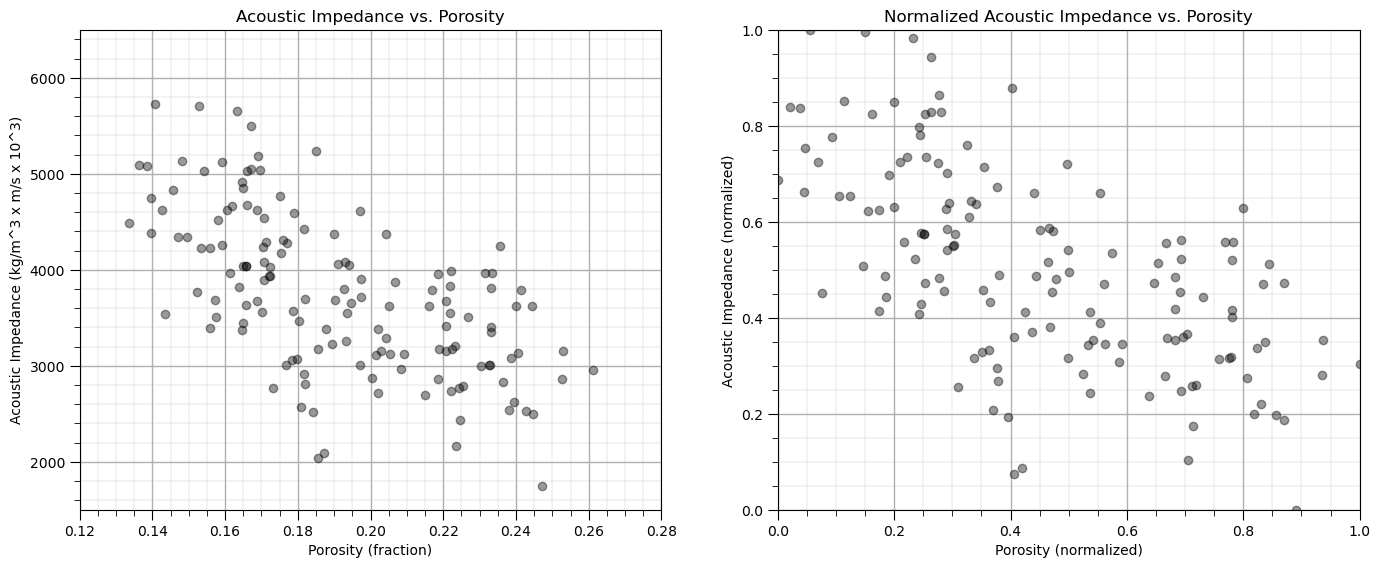

In [10]:
plt.subplot(121)                                              # scatter plot our training data 
plt.scatter(df_subset['Porosity'], df['AI'], c="black", alpha = 0.4, linewidths=1.0, edgecolors="black")
plt.title('Acoustic Impedance vs. Porosity'); plt.xlabel('Porosity (fraction)'); plt.ylabel('Acoustic Impedance (kg/m^3 x m/s x 10^3)')
plt.xlim(por_min, por_max); plt.ylim(AI_min, AI_max); add_grid();

plt.subplot(122)                                              # scatter plot our normalized training data  
plt.scatter(df_subset['Norm_Porosity'], df['Norm_AI'], c="black", alpha = 0.4, linewidths=1.0, edgecolors="black")
plt.title('Normalized Acoustic Impedance vs. Porosity'); plt.xlabel('Porosity (normalized)'); plt.ylabel('Acoustic Impedance (normalized)')
plt.xlim(0.0,1.0); plt.ylim(0.0,1.0); add_grid();
plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.0, wspace=0.2, hspace=0.2); plt.show()

### Calculating K-Medoids by Hand 
The code below will calculate k-medoid clusters by hand for the unlabelled dataset.

#### Initialization 

We will initialize just like we do for K-means, but remember that K-medoids uses actual data points! Thus this needs to be reflected in our code. 

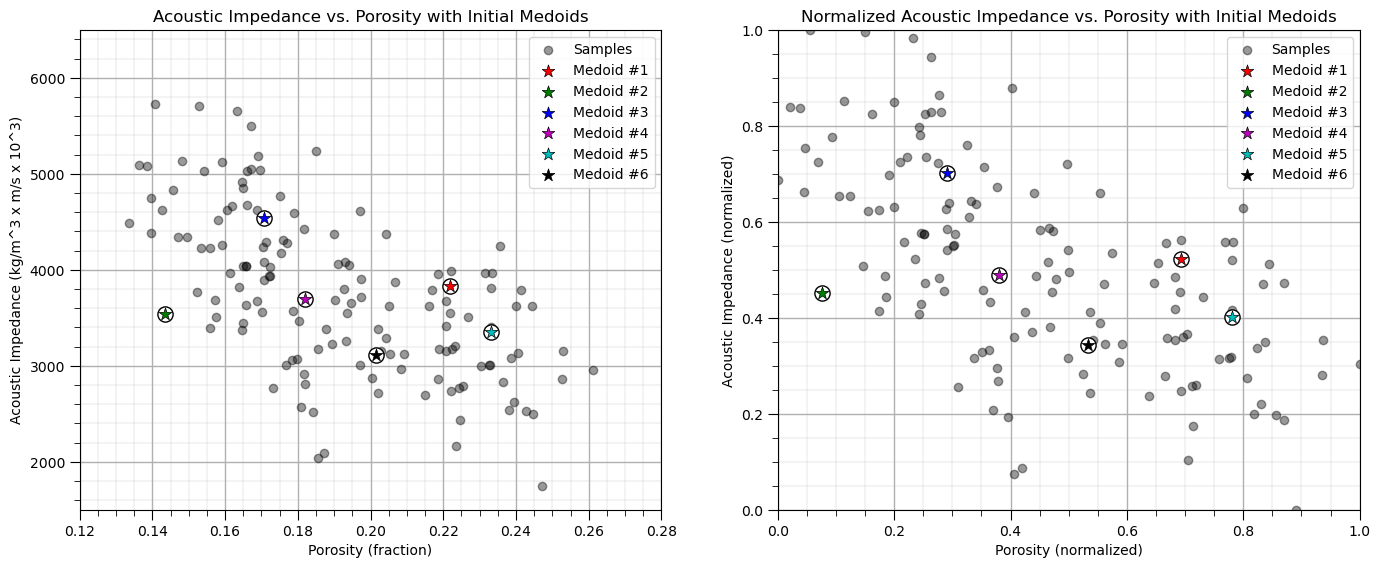

In [11]:
np.random.seed(seed)  # random seed for reproducibility
medoids = {}

# Select K random indices from your data to serve as initial medoids
initial_indices = np.random.choice(df_subset.index, size=K, replace=False)

for i, idx in enumerate(initial_indices):
    # Get the actual values from your dataset
    por = df_subset.loc[idx, 'Porosity']
    AI = df.loc[idx, 'AI']
    norm_por = df_subset.loc[idx, 'Norm_Porosity']
    norm_AI = df.loc[idx, 'Norm_AI']

    # Store in medoids dictionary
    medoids[i+1] = [por, AI, norm_por, norm_AI]
    prototypes[i, 0] = [por, AI]
    norm_prototypes[i, 0] = [norm_por, norm_AI]

# Plotting
plt.subplot(121)
plt.scatter(df_subset['Porosity'], df['AI'], c="black", alpha=0.4, linewidths=1.0, edgecolors="black", zorder=1, label='Samples')
for i in medoids.keys():
    plt.scatter(medoids[i][0], medoids[i][1], color='white', s=120, marker='o', linewidths=1.0, edgecolors="black", zorder=10)
    plt.scatter(medoids[i][0], medoids[i][1], color=colmap[i], s=90, marker='*', linewidths=0.5, edgecolors="black", zorder=20,
                label='Medoid #'+str(i))
plt.title('Acoustic Impedance vs. Porosity with Initial Medoids')
plt.xlabel('Porosity (fraction)'); plt.ylabel('Acoustic Impedance (kg/m^3 x m/s x 10^3)')
plt.xlim(por_min, por_max); plt.ylim(AI_min, AI_max); add_grid(); plt.legend(loc='upper right')

plt.subplot(122)
plt.scatter(df_subset['Norm_Porosity'], df['Norm_AI'], c="black", alpha=0.4, linewidths=1.0, edgecolors="black", label='Samples')
for i in medoids.keys():
    plt.scatter(medoids[i][2], medoids[i][3], color='white', s=120, marker='o', linewidths=1.0, edgecolors="black", zorder=10)
    plt.scatter(medoids[i][2], medoids[i][3], color=colmap[i], s=90, marker='*', linewidths=0.5, edgecolors="black", zorder=20,
                label='Medoid #'+str(i))
plt.title('Normalized Acoustic Impedance vs. Porosity with Initial Medoids')
plt.xlabel('Porosity (normalized)'); plt.ylabel('Acoustic Impedance (normalized)')
plt.xlim([0, 1]); plt.ylim([0, 1]); add_grid(); plt.legend(loc='upper right')

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.0, wspace=0.2, hspace=0.2)
plt.show()

#### Assignment of Training Data

Now we have to assign the training data to the nearest prototype (just like k-means!) Remember that we have a function to do this.

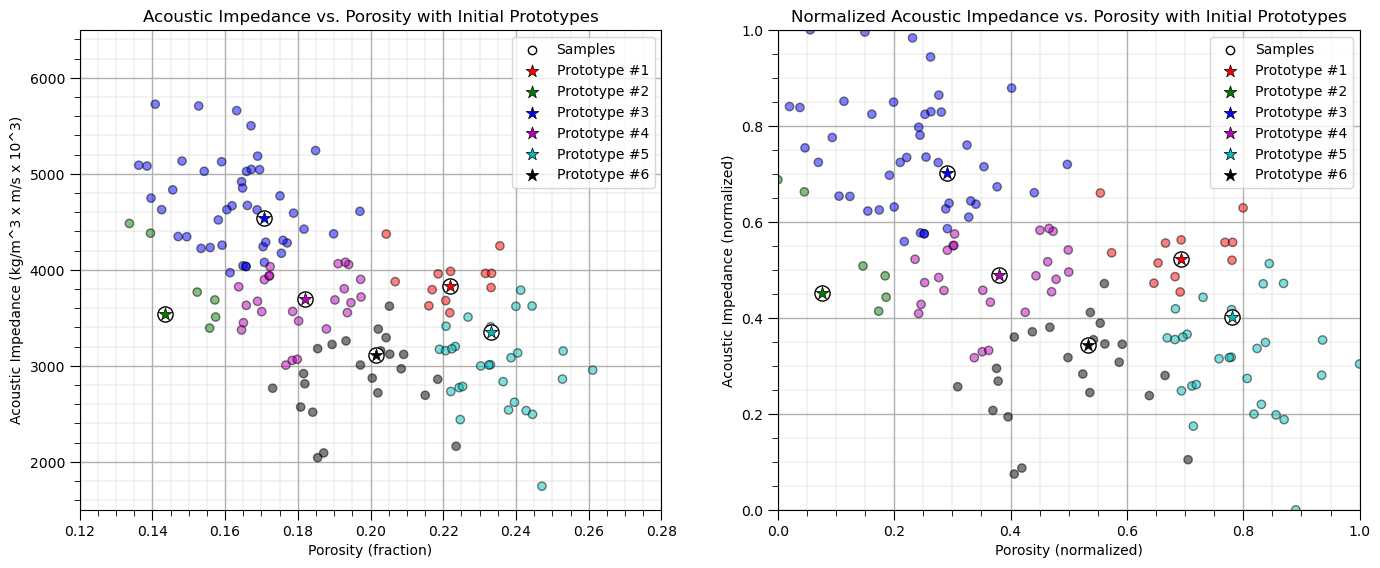

In [12]:
assignment(df, medoids)                                     # assign training data to the nearest prototype

plt.subplot(121)                                              # plot the assigned training data and K prototypes
plt.scatter(df['Porosity'], df['AI'], color=df['color'], alpha=0.5, edgecolor='k'); plt.scatter(-999,-999,color='white',edgecolors='black',
                label='Samples')
for i in medoids.keys():
    plt.scatter(medoids.get(i)[0], medoids.get(i)[1],color='white',s=120,marker='o',linewidths=1.0, edgecolors="black",zorder=10)
    plt.scatter(medoids.get(i)[0], medoids.get(i)[1],color=colmap[i],s=90,marker='*',linewidths=0.5, edgecolors="black",zorder=20,
                label='Prototype #'+str(i))
plt.title('Acoustic Impedance vs. Porosity with Initial Prototypes'); plt.xlabel('Porosity (fraction)')
plt.ylabel('Acoustic Impedance (kg/m^3 x m/s x 10^3)')
plt.xlim(por_min, por_max); plt.ylim(AI_min, AI_max); add_grid(); plt.legend(loc='upper right')

plt.subplot(122)                                              # plot the normalized training data and K prototypes
plt.scatter(df_subset['Norm_Porosity'], df['Norm_AI'], c=df['color'], alpha = 0.5, linewidths=1.0, edgecolors="black")
plt.scatter(-999,-999,color='white',edgecolors='black',label='Samples')
for i in medoids.keys():
    plt.scatter(medoids.get(i)[2], medoids.get(i)[3],color='white',s=120,marker='o',linewidths=1.0, edgecolors="black",zorder=10)
    plt.scatter(medoids.get(i)[2], medoids.get(i)[3],color=colmap[i],s=90,marker='*',linewidths=0.5, edgecolors="black",zorder=20,
                label='Prototype #'+str(i))
plt.title('Normalized Acoustic Impedance vs. Porosity with Initial Prototypes'); plt.xlabel('Porosity (normalized)')
plt.ylabel('Acoustic Impedance (normalized)')
plt.xlim([0, 1]); plt.ylim([0, 1]); add_grid(); plt.legend(loc='upper right')
plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.0, wspace=0.2, hspace=0.2); plt.show()

#### Updating the Prototypes (SWAP)

Now we are on the SWAP step and consider possible better medoids!

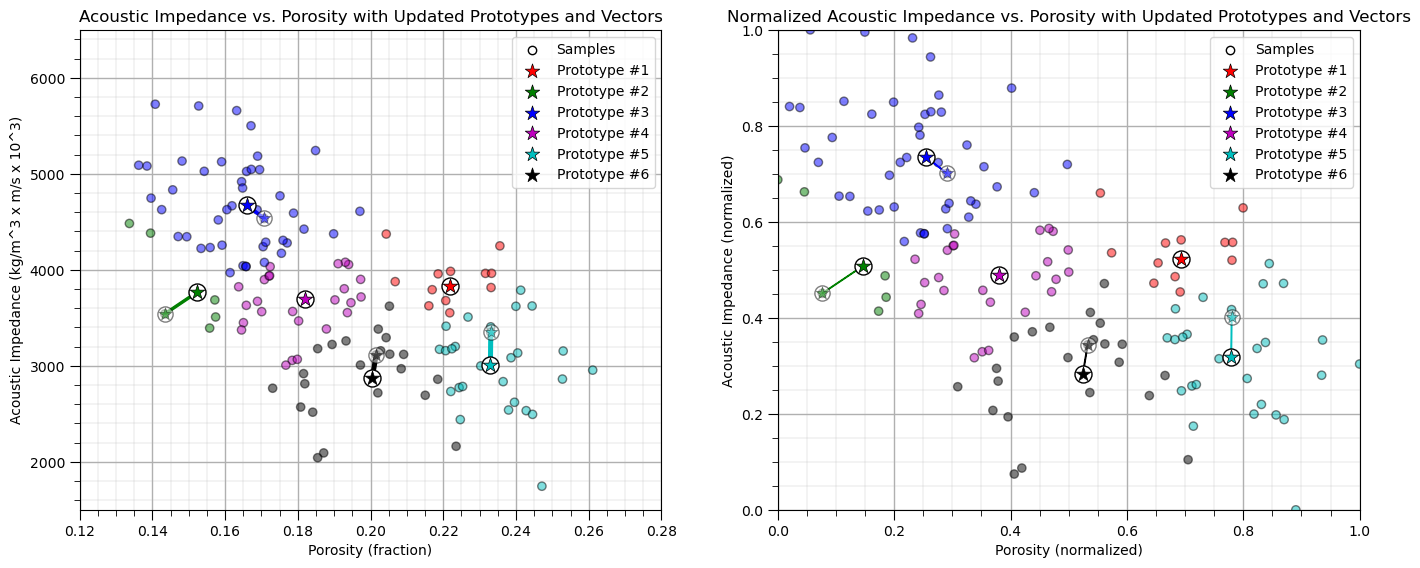

In [13]:
old_medoids = copy.deepcopy(medoids)                      # make a deep copy of the medoids for plotting vectors below
update(df,medoids,pormin,pormax,AImin,AImax)                # update the medoids to the new data assignments

plt.subplot(121)                                              # plot the assigned training data and k prototypes
ax = plt.gca()
plt.scatter(df['Porosity'], df['AI'], color=df['color'], alpha=0.5, edgecolor='k')
plt.scatter(-999,-999,color='white',edgecolors='black',label='Samples')
for i in medoids.keys():
    plt.scatter(old_medoids.get(i)[0], old_medoids.get(i)[1],color='white',s=120,marker='o',linewidths=1.0,alpha=0.5,
            edgecolors="black",zorder=10)
    plt.scatter(old_medoids.get(i)[0], old_medoids.get(i)[1],color=colmap[i],s=90,marker='*',linewidths=0.5,alpha=0.5,
            edgecolors="black",zorder=20)
    plt.scatter(medoids.get(i)[0], medoids.get(i)[1],color='white',s=150,marker='o',linewidths=1.0, edgecolors="black",zorder=10)
    plt.scatter(medoids.get(i)[0], medoids.get(i)[1],color=colmap[i],s=120,marker='*',linewidths=0.5,
            edgecolors="black",zorder=20,label='Prototype #'+str(i))
    prototypes[i-1,1] = [medoids[i][0],medoids[i][1]]; norm_prototypes[i-1,1] = [medoids[i][2],medoids[i][3]]
plt.title('Acoustic Impedance vs. Porosity with Updated Prototypes and Vectors'); plt.xlabel('Porosity (fraction)')
plt.ylabel('Acoustic Impedance (kg/m^3 x m/s x 10^3)')
plt.xlim(por_min, por_max); plt.ylim(AI_min, AI_max); add_grid(); plt.legend(loc='upper right')

for i in old_medoids.keys():                                # plot the vectors
    old_x = old_medoids[i][0]
    old_y = old_medoids[i][1]
    dx = (medoids[i][0] - old_medoids[i][0]) 
    dy = (medoids[i][1] - old_medoids[i][1]) 
    ax.arrow(old_x, old_y, dx, dy,fc=colmap[i], ec=colmap[i]); 
    
plt.subplot(122)                                              # plot the normalized assigned training data and k prototypes
ax = plt.gca()
plt.scatter(df['Norm_Porosity'], df['Norm_AI'], color=df['color'], alpha=0.5, edgecolor='k')
plt.scatter(-999,-999,color='white',edgecolors='black',label='Samples')
for i in medoids.keys():
    plt.scatter(old_medoids.get(i)[2], old_medoids.get(i)[3],color='white',s=120,marker='o',linewidths=1.0,alpha=0.5,
        edgecolors="black",zorder=10)
    plt.scatter(old_medoids.get(i)[2], old_medoids.get(i)[3],color=colmap[i],s=90,marker='*',linewidths=0.5,alpha=0.5,
        edgecolors="black",zorder=20)
    plt.scatter(medoids.get(i)[2], medoids.get(i)[3],color='white',s=150,marker='o',linewidths=1.0, edgecolors="black",zorder=10)
    plt.scatter(medoids.get(i)[2], medoids.get(i)[3],color=colmap[i],s=120,marker='*',linewidths=0.5, edgecolors="black",zorder=20,
        label='Prototype #'+str(i))
plt.title('Normalized Acoustic Impedance vs. Porosity with Updated Prototypes and Vectors'); plt.xlabel('Porosity (normalized)')
plt.ylabel('Acoustic Impedance (normalized)')
plt.xlim([0, 1]); plt.ylim([0, 1]); add_grid(); plt.legend(loc='upper right')

for i in old_medoids.keys():                                # plot the vectors
    old_x = old_medoids[i][2]
    old_y = old_medoids[i][3]
    dx = (medoids[i][2] - old_medoids[i][2]) 
    dy = (medoids[i][3] - old_medoids[i][3]) 
    ax.arrow(old_x, old_y, dx, dy,fc=colmap[i], ec=colmap[i])
      
plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.0, wspace=0.2, hspace=0.2); plt.show()

#### Repeat Assignment of the Training Data

Again we repeat this step. 

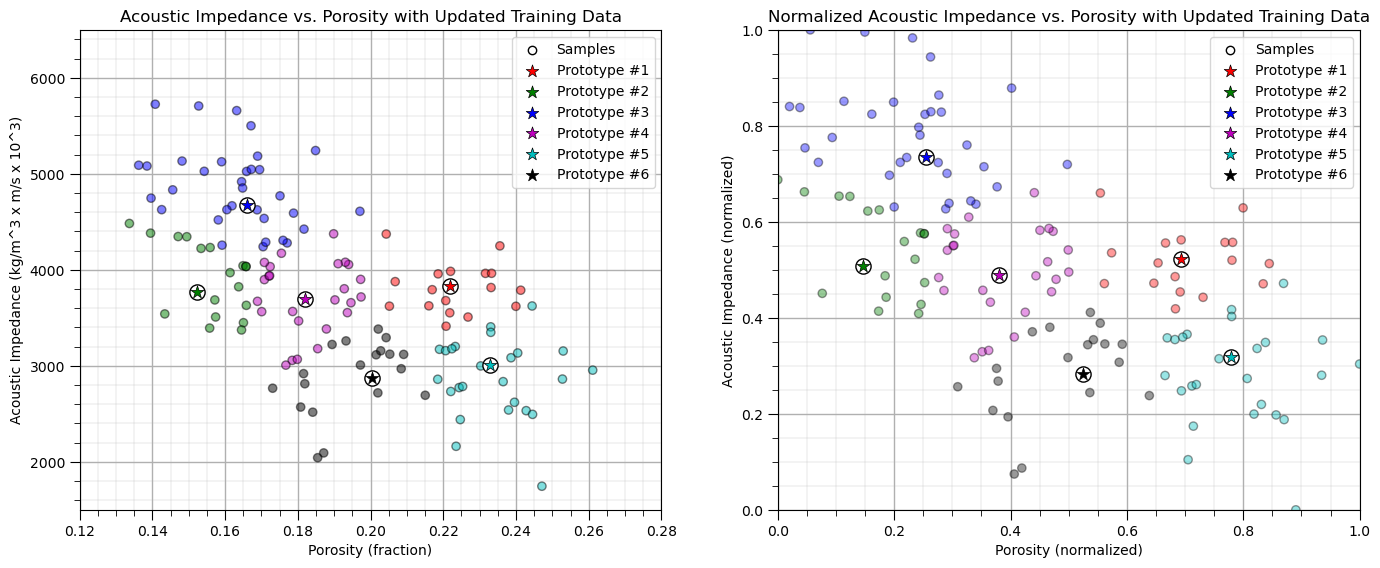

In [14]:
assignment(df, medoids)                                     # assign samples to nearest prototype

plt.subplot(121)                                              # plot the assigned training data and K prototypes
plt.scatter(df['Porosity'], df['AI'], color=df['color'], alpha=0.5, edgecolor='k'); plt.scatter(-999,-999,color='white',
    edgecolors='black',label='Samples')
for i in medoids.keys():
    plt.scatter(medoids.get(i)[0], medoids.get(i)[1],color='white',s=120,marker='o',linewidths=1.0, edgecolors="black",zorder=10)
    plt.scatter(medoids.get(i)[0], medoids.get(i)[1],color=colmap[i],s=90,marker='*',linewidths=0.5, edgecolors="black",zorder=20,
            label='Prototype #'+str(i))
plt.title('Acoustic Impedance vs. Porosity with Updated Training Data'); plt.xlabel('Porosity (fraction)')
plt.ylabel('Acoustic Impedance (kg/m^3 x m/s x 10^3)')
plt.xlim(por_min, por_max); plt.ylim(AI_min, AI_max); add_grid(); plt.legend(loc='upper right')

plt.subplot(122)                                              # plot the normalized training data and K prototypes
plt.scatter(df_subset['Norm_Porosity'], df['Norm_AI'], c=df['color'], alpha = 0.4, linewidths=1.0, edgecolors="black")
plt.scatter(-999,-999,color='white',edgecolors='black',label='Samples')
for i in medoids.keys():
    plt.scatter(medoids.get(i)[2], medoids.get(i)[3],color='white',s=120,marker='o',linewidths=1.0, edgecolors="black",zorder=10)
    plt.scatter(medoids.get(i)[2], medoids.get(i)[3],color=colmap[i],s=90,marker='*',linewidths=0.5, edgecolors="black",
            zorder=20,label='Prototype #'+str(i))
plt.title('Normalized Acoustic Impedance vs. Porosity with Updated Training Data'); plt.xlabel('Porosity (normalized)')
plt.ylabel('Acoustic Impedance (normalized)')
plt.xlim([0, 1]); plt.ylim([0, 1]); add_grid(); plt.legend(loc='upper right')
plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.0, wspace=0.2, hspace=0.2); plt.show()

#### Iterate Until Convergence

We now iterate until we find the medoid that minimizes the cost function.

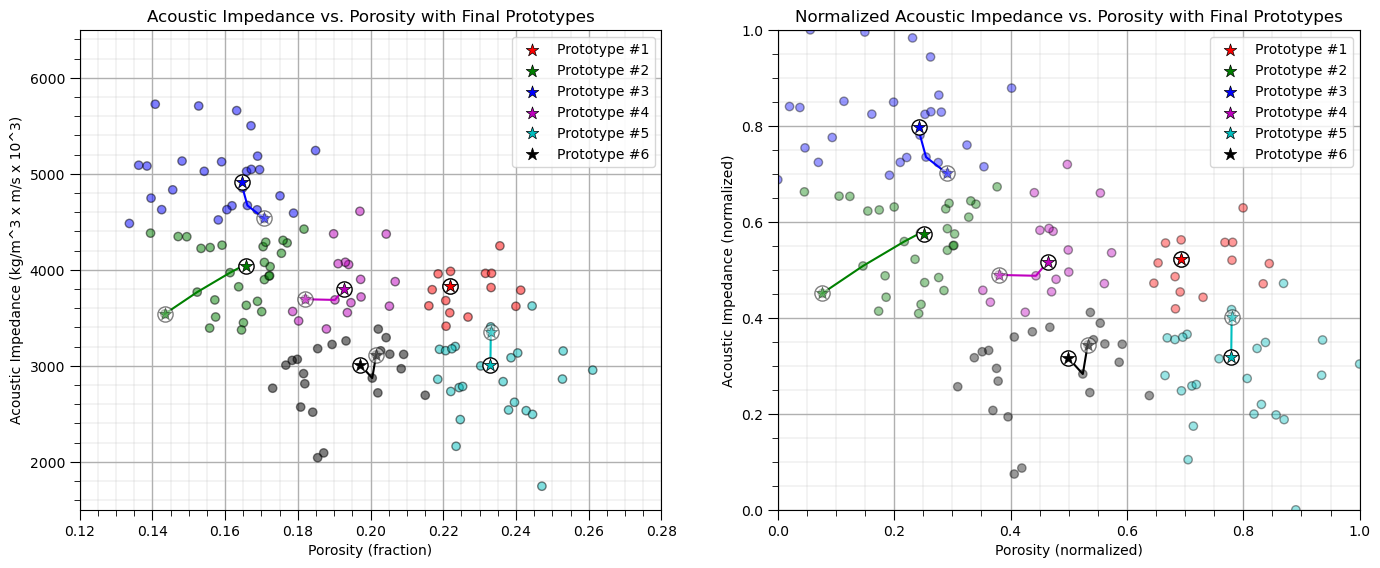

In [15]:
iteration = 2                                                 # initialize a counter, we already completed iteration 0 and 1 above
while True:
    closest_medoids = df['closest'].copy(deep=True)
    update(df,medoids,pormin,pormax,AImin,AImax)
    for i in medoids.keys():
        prototypes[i-1,iteration] = [medoids[i][0],medoids[i][1]]
        norm_prototypes[i-1,iteration] = [medoids[i][2],medoids[i][3]]
    assignment(df, medoids)
    if closest_medoids.equals(df['closest']):
        break
    iteration = iteration + 1

plt.subplot(121)                                              # plot the assigned training data and K prototypes
plt.scatter(df['Porosity'], df['AI'], color=df['color'], alpha=0.5, edgecolor='k')
for i in medoids.keys():
    plt.scatter(prototypes[i-1,0,0], prototypes[i-1,0,1],color='white',s=120,marker='o',linewidths=1.0,alpha=0.5,edgecolors="black",zorder=10)
    plt.scatter(prototypes[i-1,0,0], prototypes[i-1,0,1],color=colmap[i],s=90,marker='*',linewidths=0.5,alpha=0.5,edgecolors="black",zorder=20)
    plt.scatter(medoids.get(i)[0], medoids.get(i)[1],color='white',s=120,marker='o',linewidths=1.0, edgecolors="black",zorder=10)
    plt.scatter(medoids.get(i)[0], medoids.get(i)[1],color=colmap[i],s=90,marker='*',linewidths=0.5, edgecolors="black",
        zorder=20,label='Prototype #'+str(i))
    plt.plot(prototypes[i-1,:iteration+1,0],prototypes[i-1,:iteration+1,1],color=colmap[i],zorder = 1)
plt.title('Acoustic Impedance vs. Porosity with Final Prototypes'); plt.xlabel('Porosity (fraction)')
plt.ylabel('Acoustic Impedance (kg/m^3 x m/s x 10^3)')
plt.xlim(por_min, por_max); plt.ylim(AI_min, AI_max); add_grid(); plt.legend(loc='upper right')

plt.subplot(122)                                              # plot the training data and K prototypes
plt.scatter(df_subset['Norm_Porosity'], df['Norm_AI'], c=df['color'], alpha = 0.4, linewidths=1.0, edgecolors="black")
for i in medoids.keys():
    plt.scatter(norm_prototypes[i-1,0,0], norm_prototypes[i-1,0,1],color='white',s=120,marker='o',linewidths=1.0,alpha=0.5,
            edgecolors="black",zorder=10)
    plt.scatter(norm_prototypes[i-1,0,0], norm_prototypes[i-1,0,1],color=colmap[i],s=90,marker='*',linewidths=0.5,alpha=0.5,
            edgecolors="black",zorder=20)
    plt.scatter(medoids.get(i)[2], medoids.get(i)[3],color='white',s=120,marker='o',linewidths=1.0, edgecolors="black",zorder=10)
    plt.scatter(medoids.get(i)[2], medoids.get(i)[3],color=colmap[i],s=90,marker='*',linewidths=0.5, edgecolors="black",
            zorder=20,label='Prototype #'+str(i))
    plt.plot(norm_prototypes[i-1,:iteration+1,0],norm_prototypes[i-1,:iteration+1,1],color=colmap[i],zorder = 1)
plt.title('Normalized Acoustic Impedance vs. Porosity with Final Prototypes'); plt.xlabel('Porosity (normalized)')
plt.ylabel('Acoustic Impedance (normalized)')
plt.xlim([0, 1]); plt.ylim([0, 1]); add_grid(); plt.legend(loc='upper right')
plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.0, wspace=0.2, hspace=0.2); plt.show()

#### K-Medoids with scikit-learn

Let's try the algorithm but from scikit-learn!

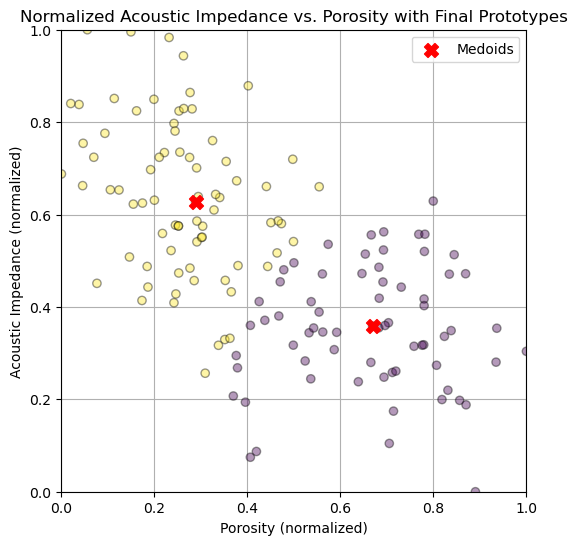

In [16]:
K = 2
seed = 42  # make sure you define seed

# Fit K-medoids
kmedoids = KMedoids(
    n_clusters=K,
    random_state=seed,
    method='pam',
    metric='euclidean'
).fit(df[['Norm_Porosity','Norm_AI']])

# Add cluster labels
df['KMedoids'] = kmedoids.labels_ + 1

# Plot
plt.figure(figsize=(6,6))
plt.scatter(df['Norm_Porosity'], df['Norm_AI'], c=df['KMedoids'], alpha=0.4, linewidths=1.0, edgecolors="black")
plt.scatter(kmedoids.cluster_centers_[:,0], kmedoids.cluster_centers_[:,1], 
            c='red', marker='X', s=100, label='Medoids')
plt.title('Normalized Acoustic Impedance vs. Porosity with Final Prototypes')
plt.xlabel('Porosity (normalized)')
plt.ylabel('Acoustic Impedance (normalized)')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.grid(True)
plt.legend()
plt.show()


#### Selecting the Optimum Number of Clusters

Just like k-means clustering, k-medoid clustering also has a k-number of clusters input. It can be determined domain expertise, but often is a weakness of these partitioning types of clustering (like k-means and k-medoids) as the optimal number of clusters is somewhat subjective. There are two methods to determine the optimal number of clusters:
- Direct Methods: involves optimizing a criterion, Ex: Elbow and Silhouette
- Statistical Testing Methods: involves evaluating evidence with a null hypothesis, Ex: Gap statistic.

The elbow method is a common method. We will use this method in this workflow. Recall that we want to minimize the total within-cluster sum of square (WSS) for partitioning methods like medoid clustering (and k-means). The elbow method examines the total WSS as a function of how many clusters there are. The optimal number of clusters would be one where adding another cluster does not improve the the total WSS. The steps to do the elbow method are:
1. Perform the clustering algorithm (k-medoids in our case) for varying values of K.
2. Determine the total WSS for each K
3. Plot the WSS based on each K
4. The location of the bend in the graph is the optimal amount of clusters.

(Source: https://www.datanovia.com/en/lessons/determining-the-optimal-number-of-clusters-3-must-know-methods/ )

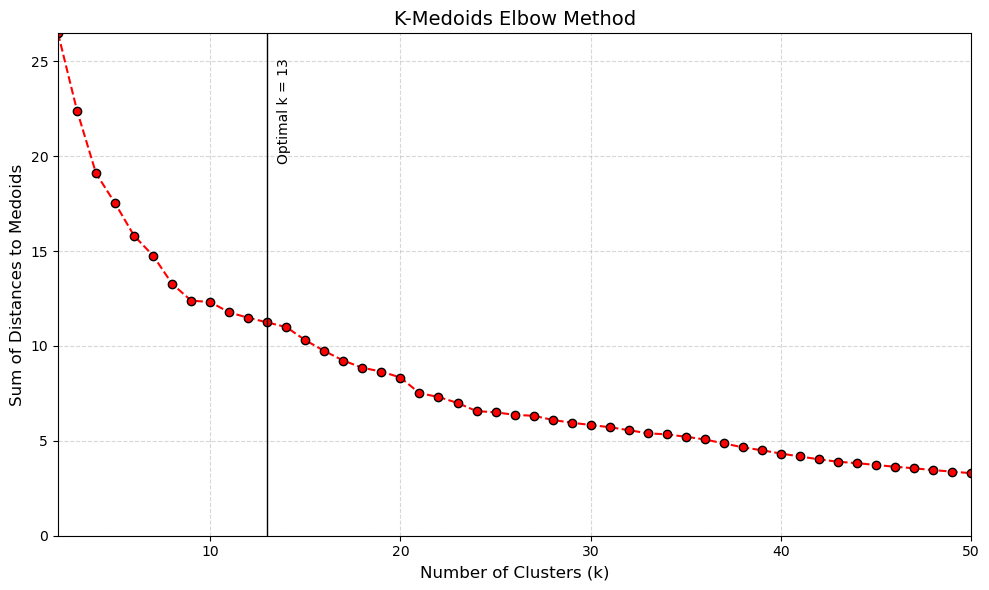

In [17]:
# parameters 
max_K = 50
optimal_k = 13
data = df[['Norm_Porosity', 'Norm_AI']].values

# compute inertia 
inertia_values = []

for k in range(2, max_K + 1):
    model = KMedoids(
        n_clusters=k,
        metric='euclidean',
        init='k-medoids++',
        random_state=14
    ).fit(data)
    
    inertia_values.append(model.inertia_)

# plot elbow curve 
plt.figure(figsize=(10, 6))

ks = range(2, max_K + 1)

plt.plot(ks, inertia_values, '--o', color='red', 
         markeredgecolor='black', markersize=6, linewidth=1.5)

# vertical line showing optimal k
plt.axvline(optimal_k, color='black', linestyle='-', linewidth=1)
plt.text(optimal_k + 0.5, 0.95 * max(inertia_values),
         f'Optimal k = {optimal_k}',
         rotation=90, va='top')

# labels and title (formatting, etc)
plt.title('K-Medoids Elbow Method', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Sum of Distances to Medoids', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(2, max_K)
plt.ylim(0, max(inertia_values))

plt.tight_layout()
plt.show()


#### Summary Tables 
K-Medoids vs K-Means?
| Feature | Use K-means? | Use K-medoids? |
|----------|----------|----------|
| Centroid   | Mean of cluster points   | Actual data point   |
| Distance metric   | Euclidean distance   | Any distance metric (Manhattan, Euclidean, etc)  |
| Outlier sensitivity    | Sensitive  | Robust   |
| Computational cost    | Faster   | Slower (as a result of pairwise distance calculations)   |
| Best for   | Large datasets, spherical clusters  | Small datasets, non-spherical clusters   |

When to use K-Means vs K-medoids? 
| Scenario | Use K-means? | Use K-medoids? |
|----------|----------|----------|
| Large datasets   | Yes   | No   |
| Data with outliers   | No   | Yes  |
| Spherical cluster    | Yes   | Yes   |
| Arbitrary-shaped clusters    | No   | Yes   |
| Fast computation needed    | Yes   | No   |

(Source: https://medium.com/@prasanth32888/k-medoids-clustering-cee6042155c6 )
NOTE: The tables are taken almost exactly as they are written on Prasanth Babu's blog post. All credit goes to him. Thank you for these well-organized tables, Prasanth!


#### Conclusion

Ultimately, K-medoids clustering is another partitioning clustering method to consider. It has advantages to the K-means clustering that we are used to: it can deal with outliers, can be used for arbitrary-shaped clusters and does not need fast computation, but does not work as well with large datasets. The benefit of K-medoids clustering is that the center of each cluster is an actual data point rather than an arbitrary point. It is my recommendation to use K-medoids clustering if you do not need to compromise the speed of your computations. 

#### About the Student

Amber Nguyen is a current master's student at the Jackson School of Geosciences. She earned her B.S. in Geosystems Engineering and Hydrogeology at Cockrell School of Engineering, and the Jackson School of Geosciences, at The University of Texas at Austin. Her specialization is in coastal hydrogeology where she works with groundwater discharge and its mixing dynamics with seawater. Her career goals are to be a professor conducting research with a focus on sustainability. 

#### About the Supervising Professor

Michael Pyrcz is a professor in the Cockrell School of Engineering, and the Jackson School of Geosciences, at The University of Texas at Austin, where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

the principal investigator of the Energy Analytics freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

an associate editor for Computers and Geosciences, and a board member for Mathematical Geosciences, the International Association for Mathematical Geosciences.

Michael has written over 70 peer-reviewed publications, a Python package for spatial data analytics, co-authored a textbook on spatial data analytics, Geostatistical Reservoir Modeling and author of two recently released e-books, Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy and Applied Machine Learning in Python: a Hands-on Guide with Code.

All of Michael’s university lectures are available on his YouTube Channel with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his GitHub account, to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his Website.

Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you!

Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

Michael

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: Twitter | GitHub | Website | GoogleScholar | Geostatistics Book | YouTube | Applied Geostats in Python e-book | Applied Machine Learning in Python e-book | LinkedIn

#### REFERENCES

- Babu, P. (2025, January 31). K-Medoids Clustering (ML). Medium. https://medium.com/@prasanth32888/k-medoids-clustering-cee6042155c6 
- Clustering with K-medoids, CLARA and common-nearest-neighbors. scikit. (2019). https://scikit-learn-extra.readthedocs.io/en/stable/modules/cluster.html 
- Kassambara, A. (2018, October 21). Determining the optimal number of clusters: 3 must know methods. Datanovia. https://www.datanovia.com/en/lessons/determining-the-optimal-number-of-clusters-3-must-know-methods/
- Pyrcz, M.J., 2024, Applied Machine Learning in Python: A Hands-on Guide with Code [e-book]. Zenodo. doi:10.5281/zenodo.15169138 DOI
- Pyrcz, M.J., 2024, MachineLearningDemos: Python Machine Learning Demonstration Workflows Repository (0.0.3) [Software]. Zenodo. DOI: 10.5281/zenodo.13835312. GitHub repository: GeostatsGuy/MachineLearningDemos DOI